# Metagenomic Analysis: The Global Gut Microbiome
### PA 1 – Applied Digital Life Sciences – Digital Health
**Authors:** Ajna Binaki, Dario Filippone, Peter Pan, Naruto, Gojo, Sukuna

## Introduction
Write text here.

## 1. Imports

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Loading

In [46]:
path_metadata      = '../data/raw/Human_atlas/sampleID.csv'
path_microbiome_raw = '../data/raw/Human_atlas/vect_atlas.csv'

metadata      = pd.read_csv(path_metadata)
microbiome_raw = pd.read_csv(path_microbiome_raw, index_col=0)

microbiome    = microbiome_raw.transpose()
combined_data = pd.merge(metadata, microbiome, left_on='sample.ID', right_index=True, how='inner')

print(f"Dataset shape: {combined_data.shape[0]} samples, {combined_data.shape[1]} columns")
combined_data.to_csv('../data/processed/01_combined_data.csv', index=False)

display(combined_data.head())

Dataset shape: 6014 samples, 2004 columns


,sample.ID,BioProject,type,Age,Gender,BMI,Geography,Sequencer,MgsRichness,GeneRichness,...,msp_2176,msp_2178,msp_2180,msp_2191,msp_2195,msp_2196,msp_2207,msp_2209,msp_2210,msp_2211
0,ERS608599,PRJEB7774,Disease,64.0,Male,29.0,Austria,Illumina HiSeq 2000,184,563013,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERS608499,PRJEB7774,Control,68.0,Male,32.0,Austria,Illumina HiSeq 2000,265,686859,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERS608489,PRJEB7774,Control,60.0,Female,22.0,Austria,Illumina HiSeq 2000,228,616715,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERS608554,PRJEB7774,Disease,70.0,Male,34.0,Austria,Illumina HiSeq 2000,236,628862,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERS608521,PRJEB7774,Control,68.0,Male,23.0,Austria,Illumina HiSeq 2000,254,627031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Demographics
Overview of sample distribution by country and health status.

In [47]:
combined_data["type"] = combined_data["type"].astype("category")

healthy_data = combined_data[combined_data["type"] == "Control"]
disease_data = combined_data[combined_data["type"] == "Disease"]

print(f"Total samples:  {len(combined_data)}")
print(f"  Healthy:      {len(healthy_data)}")
print(f"  Disease:      {len(disease_data)}")

Total samples:  6014
  Healthy:      3292
  Disease:      2713


In [48]:
# Samples per country, split by health status
country_type = (
    combined_data
    .groupby(["Geography", "type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .assign(Total=lambda df: df.sum(axis=1))
    .sort_values("Total", ascending=False)
)

print("--- Samples per Country ---")
print(country_type.to_string())

--- Samples per Country ---
type        Control  Disease  Total
Geography                          
China           730     1018   1748
USA             666      242    908
Japan           291      353    644
France           61      314    375
UK              259       90    349
Denmark         335        0    335
Spain            14      188    202
Fiji            193        0    193
Italy            63      129    192
Germany          93       91    184
Sweden           58      114    172
Austria          63       93    156
India           110       30    140
Madagascar      112        0    112
Mongolia        110        0    110
Luxembourg       52       47     99
Peru             36        0     36
Tanzania         27        0     27
Thailand         15        0     15
Finland           4        4      8


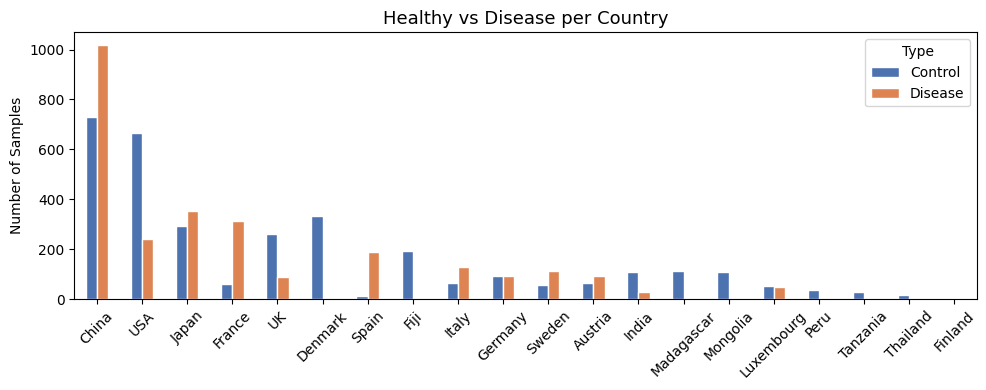

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))

country_type[["Control", "Disease"]].plot(
    kind="bar", ax=ax,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)

ax.set_title("Healthy vs Disease per Country", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type")
plt.tight_layout()
plt.show()

# 4. Preprocessing

Before applying analytical methods or machine learning pipelines, raw metagenomic data must undergo rigorous preprocessing to account for its unique mathematical properties. Bacterial abundance tables are inherently **sparse** and **compositional**, with zero-inflation often reaching 80–95%. This sparsity arises because individual samples only contain a specific subset of the global microbial diversity, and limited sequencing depth—often referred to as **sampling effort**—can lead to a failure in capturing rare taxa.

## Metadata and Feature Description

| Column        | Description |
|--------------|------------|
| `sample.ID`  | Unique identifier per sample. |
| `BioProject` | Source study; used to identify and mitigate potential **batch effects**. |
| `type`       | Binary classification: Control (healthy) vs. Disease. |
| `Age` / `Gender` | Demographic covariates used for cohort matching. |
| `BMI`        | Body Mass Index; the primary phenotypic variable for obesity analysis. |
| `Geography`  | Country of origin; a major driver of microbial variance. |
| `MgsRichness`| Alpha-diversity metric (Species Richness) per sample. |
| `msp_XXXX`   | Metagenomic Species Pangenome (MSP) relative abundance. |

---

## Preprocessing Workflow

To ensure a robust comparison between geographical cohorts and phenotypes, the following pipeline was implemented based on established best practices:

### 1. Quality and Prevalence Filtering

Following the recommendation to control for technical variation and sequencing errors, filtering was performed **prior** to normalization.

- **Sample Filtering (Richness):** Samples with an `MgsRichness` below a defined threshold (e.g., the 5th percentile) were excluded. This ensures that only samples with sufficient "sampling effort" are compared, as extremely low richness typically indicates technical artifacts or poor DNA yield.

- **Taxa Filtering (Prevalence):** MSPs present in fewer than 10% of samples were removed. This step is crucial because most apparent sequence diversity in marker gene and metagenomic data often arises from sequencing errors. Removing low-prevalence taxa reduces the "Multiple Testing" burden and focuses the analysis on stable microbial signatures.

### 2. Normalization: Total Sum Scaling (TSS)

To account for varying sequencing depths across different library preparations, counts were normalized to **relative abundances**. Each sample was divided by its row sum so that the features sum to 1.0:

$$
x_{rel} = \frac{x_i}{\sum x_i}
$$

While this makes samples comparable regardless of original scale, it reinforces the **compositional** nature of the data, where features are no longer independent.

### 3. Transformation: Centered Log-Ratio (CLR)

Microbiome data is highly right-skewed and compositional; an increase in one taxon's proportion forces a decrease in others. To move the data from the Aitchison simplex into Euclidean space, we applied the **Centered Log-Ratio (CLR)** transformation. This transformation is "compositionally aware" and allows for the application of standard statistical tools like PCA and Random Forest without the biases inherent in proportional data.

The CLR is calculated as:

$$
CLR(x) = \left[ \ln \frac{x_1}{g(x)}, \dots, \ln \frac{x_n}{g(x)} \right]
$$

where $g(x)$ represents the geometric mean of the abundances within the sample.

In [89]:
# --- Configuration & Constants ---
RICHNESS_Q = 0.05
PREVALENCE_T = 0.10

# Initial Filtering: Extract Healthy Cohort
# Frop Type column
healthy_df = combined_data[combined_data["type"] == "Control"].drop(columns=["type"]).copy()

# Identify Column Groups
msp_cols = [c for c in healthy_df.columns if c.startswith('msp')]
meta_cols = [c for c in healthy_df.columns if not c.startswith('msp')]

# Sample Filtering (Richness)
# Calculate richness for each sample (number of MSPs with abundance > 0)
richness = healthy_df[msp_cols].gt(0).sum(axis=1)
richness_threshold = richness.quantile(RICHNESS_Q)

filtered_df = healthy_df[richness >= richness_threshold].copy()

# Pravalence Filtering, Remove MSPs that are present in less than 10% of samples
prevalence = (filtered_df[msp_cols] > 0).mean()
keep_msps = prevalence[prevalence >= PREVALENCE_T].index.tolist()

# Assembly of Dataset
final_data = filtered_df[meta_cols + keep_msps]

# Save output
final_data.to_csv('../data/processed/03_filtered_healthy_data.csv', index=False)

# Checking the results
print(f"Shape:    {final_data.shape}")
print(f"Taxa:     {len(keep_msps)} kept from {len(msp_cols)}")
print(f"Min Prev: {(final_data[keep_msps] > 0).mean().min():.1%}")
print(f"Richness: {final_data[keep_msps].gt(0).sum(axis=1).min()} to {final_data[keep_msps].gt(0).sum(axis=1).max()}")



Shape:    (3128, 609)
Taxa:     596 kept from 1990
Min Prev: 10.0%
Richness: 53 to 388


In [76]:
# Normalization (TSS)
normalized_df = final_data.copy()
normalized_df[keep_msps] = normalized_df[keep_msps].div(normalized_df[keep_msps].sum(axis=1), axis=0)
normalized_df.to_csv('../data/processed/04_normalized_healthy_data.csv', index=False)

In [91]:
# CLR Transformation
clr_df = normalized_df.copy()

log_data = np.log(clr_df[keep_msps] + 1e-6)
clr_df[keep_msps] = log_data.sub(log_data.mean(axis=1), axis=0)
clr_df.to_csv('../data/processed/05_clr_healthy_data.csv', index=False)

In [93]:
print("--- 🔍 Datencheck & Integrität ---")

# 1. Check auf Rechenfehler (NaNs oder Unendlichkeit)
# Log(0) würde "inf" erzeugen, fehlende Daten "NaN"
has_nans = clr_df[keep_msps].isna().any().any()
has_infs = np.isinf(clr_df[keep_msps]).any().any()
print(f"Fehlende Werte (NaNs)?    {'❌ JA' if has_nans else '✅ Nein'}")
print(f"Unendliche Werte (Infs)? {'❌ JA' if has_infs else '✅ Nein'}")

# 2. Check der CLR-Zentrierung
# Bei CLR muss der Mittelwert jeder Zeile (Probe) fast exakt 0 sein
max_row_mean = clr_df[keep_msps].mean(axis=1).abs().max()
is_centered = max_row_mean < 1e-12 
print(f"CLR korrekt zentriert?    {'✅ Ja' if is_centered else '❌ Nein'} (Abweichung: {max_row_mean:.2e})")

# 3. Check der Vollständigkeit (Dimensionen)
print(f"Anzahl Proben (Samples):  {clr_df.shape[0]}")
print(f"Anzahl Bakterien (MSPs):  {len(keep_msps)}")

# 4. Check der Metadaten
# Wir prüfen, ob deine Zusatzinfos (alles was nicht 'msp' ist) noch da sind
meta_cols_found = [c for c in clr_df.columns if not c.startswith('msp')]
print(f"Metadaten erhalten?       {', '.join(meta_cols_found) if meta_cols_found else '❌ Keine gefunden'}")

print("---------------------------------")

--- 🔍 Datencheck & Integrität ---
Fehlende Werte (NaNs)?    ✅ Nein
Unendliche Werte (Infs)? ✅ Nein
CLR korrekt zentriert?    ✅ Ja (Abweichung: 1.10e-13)
Anzahl Proben (Samples):  3128
Anzahl Bakterien (MSPs):  596
Metadaten erhalten?       sample.ID, BioProject, Age, Gender, BMI, Geography, Sequencer, MgsRichness, GeneRichness, enteroType, Disease, IGC2mappedReadCount, IGC2mappedPercent
---------------------------------
